# TP2 - Adrián Lapaz

## Objetivo:
Implementar un detector de máximo enfoque sobre un video aplicando técnicas de análisis espectral similar al que utilizan las
cámaras digitales modernas. El video a procesar será: “focus_video.mov”.
### 1. Se debe implementar un algoritmo que dada una imagen, o región, calcule la métrica propuesta en el paper "Image Sharpness Measure for Blurred Images in Frequency Domain“ y realizar tres experimentos:
1. Medición sobre todo el frame
2. Medición sobre una ROI ubicada en el centro del frame. Area de la ROI = 5 o 10% del area total del frame.
3. Medición sobre una matriz de enfoque compuesta por un arreglo de NxM elementos rectangulares equiespaciados. N y M son valores arbitrarios, probar con varios valores 3x3, 7x5, etc … (al menos 3) 

Para cada experimento se debe presentar :
- Una curva o varias curvas que muestren la evolución de la métrica frame a frame donde se vea claramente cuando el algoritmo detecto el punto 
de máximo enfoque.
- Video con la ROI o matriz, graficada en rojo y superpuesta al video original para los frames que no están en foco y verde para los frames
donde se detecta la condición de máximo enfoque

---
### 1.1. Medición sobre todo el frame

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ========================================
# MÉTRICA DE ENFOQUE
# ========================================
def calcular_metrica_enfoque(img: np.ndarray) -> float:
    """Calcula la métrica de enfoque FM para una imagen basado en Fourier.

    Implementa el algoritmo 'Frequency Domain Image Blur Measure (FM)' descrito
    por De y Masilamani [Ref Paper, si se conoce], que cuantifica la nitidez
    contando la proporción de componentes de frecuencia en el espectro de
    magnitud que superan un umbral relativo al valor máximo del espectro.

    Args:
        img (np.ndarray): La imagen de entrada. Puede ser una matriz NumPy en
                          escala de grises (M x N) o en color BGR (M x N x 3).
                          Si es a color, se convertirá internamente a escala
                          de grises para el cálculo.

    Returns:
        float: El valor calculado de la métrica FM. Este valor es una proporción
               (teóricamente entre 0 y 1), donde un valor más alto sugiere una
               mayor presencia de altas frecuencias significativas, lo que
               generalmente se correlaciona con una imagen más nítida según
               este método específico. Devuelve 0.0 para imágenes completamente
               negras o vacías.

    Raises:
        ValueError: Si el formato de la imagen de entrada no es soportado
                    (distinto de 2D o 3D con 3 canales) o si img es None.
    """
    # --- Validación y Preprocesamiento ---
    if img is None:
        raise ValueError("La imagen de entrada no puede ser None.")

    if img.ndim == 3 and img.shape[2] == 3:
        # Convertir a escala de grises si es BGR
        gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    elif img.ndim == 2:
        # Ya está en escala de grises
        gray_img = img
    else:
        raise ValueError(
            f"Formato de imagen no soportado: {img.shape}. "
            "Se espera (M, N) o (M, N, 3)."
        )

    if gray_img.size == 0:
        # Manejar imagen vacía
        return 0.0

    rows, cols = gray_img.shape

    # --- Pasos del Algoritmo FM ---

    # 1. Calcular la Transformada de Fourier 2D
    f_transform = np.fft.fft2(gray_img)

    # 2. Centrar el espectro (mover componente DC al centro)
    f_shift = np.fft.fftshift(f_transform)

    # 3. Calcular el espectro de magnitud (AF = abs(Fc))
    magnitude_spectrum = np.abs(f_shift)

    # 4. Encontrar el valor máximo del espectro de magnitud (M = max(AF))
    max_magnitude = np.max(magnitude_spectrum)

    # 5. Calcular el umbral (thres = M / 1000)
    # Manejar caso de imagen completamente negra (M=0) para evitar división por cero
    # y devolver 0.0 ya que no hay frecuencias significativas.
    if max_magnitude < np.finfo(float).eps:  # Usar epsilon para comparación flotante
        return 0.0

    threshold = max_magnitude / 1000.0

    # 6. Contar píxeles en el espectro de magnitud > umbral (TH = sum(AF > thres))
    pixel_count_above_threshold = np.sum(magnitude_spectrum > threshold)

    # 7. Calcular la medida FM = TH / (M*N)
    # Asegurar división flotante y devolver como float estándar de Python
    iqm_fm = float(pixel_count_above_threshold) / (rows * cols)

    return iqm_fm

# --- Puedes probarla con un ejemplo ---
# if __name__ == '__main__':
#     # Carga o crea una imagen aquí
#     # Ejemplo: Crear una imagen de ruido y una versión borrosa
#     img_sharp = np.random.randint(0, 256, (512, 512), dtype=np.uint8)
#     img_blurred = cv2.GaussianBlur(img_sharp, (25, 25), 8)

#     fm_sharp = calcular_metrica_enfoque(img_sharp)
#     fm_blurred = calcular_metrica_enfoque(img_blurred)

#     print(f"Métrica FM (Nítida): {fm_sharp:.6f}")
#     print(f"Métrica FM (Borroso): {fm_blurred:.6f}")
#     # Se espera que fm_sharp > fm_blurred

# ========================================
# FUNCIONES DE VISUALIZACIÓN
# ========================================

def plot_metricas(metricas, nombre="Métrica"):
    """
    Grafica la evolución de una o varias métricas de enfoque a lo largo de los frames.

    Si se proporciona una lista de listas (métricas por ROI), grafica cada una
    con un color diferente. Si se proporciona una lista simple (métrica por frame completo),
    la grafica en azul. Marca el punto máximo de cada serie graficada.

    Args:
        metricas (list[float] | list[list[float]]): Una lista de valores de métrica (para el frame completo)
                                                     o una lista de listas de valores de métrica (una lista por cada ROI).
        nombre (str, optional): Un prefijo para el título del gráfico. Por defecto es "Métrica".
    """
    plt.figure(figsize=(20, 10))
    if isinstance(metricas[0], list):
        # Caso multi-ROI: Graficar cada ROI con un color distinto
        colores = cm.viridis(np.linspace(0, 1, len(metricas))) # Genera colores distintos
        for i, (m, c) in enumerate(zip(metricas, colores)):
            plt.plot(m, label=f'ROI {i}', color=c)
            # Encuentra y marca el máximo para esta ROI
            max_val = max(m)
            max_idx = np.argmax(m)
            plt.scatter(max_idx, max_val, color=c, s=100, marker='o', edgecolors='black', label=f'Máximo ROI {i} (Frame {max_idx})')
    else:
        # Caso frame completo: Graficar una sola línea
        plt.plot(metricas, label='Frame completo', color='blue')
        # Encuentra y marca el máximo
        max_val = max(metricas)
        max_idx = np.argmax(metricas)
        plt.scatter(max_idx, max_val, color='red', s=100, marker='o', edgecolors='black', label=f'Máximo en frame {max_idx}')

    plt.title(f'{nombre} - Evolución a través de los Frames')
    plt.xlabel('Número de Frame')
    plt.ylabel('Valor de la Métrica')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(False) 
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show() 

def reproducir_video(frames, titulo='Video'):
    """
    Muestra una secuencia de frames como un video utilizando OpenCV.

    Itera a través de la lista de frames y los muestra en una ventana.
    Se puede detener la reproducción presionando la tecla 'q'.

    Args:
        frames (list[np.ndarray]): Una lista de frames (imágenes NumPy) a reproducir.
        titulo (str, optional): El título de la ventana de reproducción. Por defecto es 'Video'.
    """
    if not frames:
        print("No hay frames para reproducir.")
        return

    for f in frames:
        cv2.imshow(titulo, f)
        # Espera 30ms por cada frame. Si se presiona 'q' (ASCII 113), sale del bucle.
        if cv2.waitKey(30) & 0xFF == ord('q'):
            break
    # Cierra todas las ventanas abiertas por OpenCV al terminar o al presionar 'q'
    cv2.destroyAllWindows()

# ========================================
# PROCESAMIENTO DE VIDEO
# ========================================

def obtener_metricas(video_path, rois=None, metric_func=calcular_metrica_enfoque):
    """
    Procesa un video para calcular la métrica de enfoque para cada frame (o ROIs dentro de cada frame).

    Lee un video frame por frame. Para cada frame, calcula la métrica de enfoque
    especificada por `metric_func`. Si se proporcionan ROIs, calcula la métrica para cada
    ROI y las almacena separadamente. Dibuja rectángulos rojos alrededor de las áreas
    (ROIs o frame completo) que se están procesando en cada frame.

    Args:
        video_path (str): La ruta al archivo de video.
        rois (list[tuple], optional): Una lista de tuplas, donde cada tupla define una
                                      Región de Interés (ROI) como (x, y, w, h).
                                      Si es None, se procesa el frame completo. Por defecto es None.
        metric_func (callable, optional): La función a usar para calcular la métrica.
                                           Debe aceptar una imagen NumPy como entrada y
                                           devolver un valor numérico.
                                           Por defecto es `calcular_metrica_enfoque`.

    Returns:
        tuple: Una tupla conteniendo:
            - frames_modificados (list[np.ndarray]): Una lista de los frames del video con
                                                     rectángulos rojos dibujados en las áreas procesadas.
            - metricas (list[float] | list[list[float]]): Una lista de valores de métrica si
                                                           `rois` es None, o una lista de listas
                                                           (una por ROI) si se proporcionan `rois`.
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error: No se pudo abrir el video en {video_path}")
        return [], []

    # Inicializa la estructura para guardar métricas
    if rois:
        metricas = [[] for _ in range(len(rois))]
    else:
        metricas = []
    frames_modificados = []

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            # Fin del video o error al leer frame
            break

        frame_copia = frame.copy() # Trabaja sobre una copia para no modificar el original si se reutiliza
        color_rectangulo = (0, 0, 255) # Rojo en BGR

        if rois:
            # Procesa cada ROI
            for i, (x, y, w, h) in enumerate(rois):
                # Extrae la región de interés del frame
                roi_frame = frame[y:y+h, x:x+w]
                # Calcula la métrica para la ROI
                metrica = metric_func(roi_frame)
                metricas[i].append(metrica)
                # Dibuja el rectángulo en la copia del frame
                cv2.rectangle(frame_copia, (x, y), (x+w, y+h), color_rectangulo, 2)
        else:
            # Procesa el frame completo
            metrica = metric_func(frame)
            metricas.append(metrica)
            # Dibuja un rectángulo alrededor de todo el frame en la copia
            cv2.rectangle(frame_copia, (0, 0), (frame.shape[1], frame.shape[0]), color_rectangulo, 2)

        # Guarda el frame modificado (con rectángulos)
        frames_modificados.append(frame_copia)

    cap.release() # Libera el recurso del video
    return frames_modificados, metricas

def resaltar_maximos(frames, metricas, rois=None):
    """
    Identifica los frames con los valores máximos de la métrica y los resalta con un rectángulo verde.

    Toma la lista de frames (posiblemente ya con rectángulos rojos) y las métricas calculadas.
    Encuentra el índice del frame donde la métrica es máxima (para cada ROI si aplica).
    Modifica esos frames específicos dibujando un rectángulo verde sobre el área correspondiente
    (ROI o frame completo) para indicar que es el de mejor enfoque según la métrica.

    Args:
        frames (list[np.ndarray]): La lista de frames (idealmente la salida de `obtener_metricas`).
        metricas (list[float] | list[list[float]]): La lista (o lista de listas) de métricas
                                                    correspondiente a los frames.
        rois (list[tuple], optional): La lista de ROIs utilizada para generar las métricas.
                                      Es necesario si `metricas` es una lista de listas.
                                      Por defecto es None.

    Returns:
        tuple: Una tupla conteniendo:
            - frames (list[np.ndarray]): La misma lista de frames de entrada, pero modificada
                                         para incluir rectángulos verdes en los frames con métrica máxima.
            - indices_max (list[int]): Una lista con el/los índice(s) del/de los frame(s)
                                       donde se encontró el valor máximo de la métrica.
                                       Si hay múltiples ROIs, contiene un índice por cada ROI.
    """
    if not frames or not metricas:
        print("Error: Se necesitan frames y métricas para resaltar máximos.")
        return frames, []

    color_resaltado = (0, 255, 0) # Verde en BGR

    if isinstance(metricas[0], list):
        # Caso multi-ROI: encuentra el índice máximo para cada ROI
        if rois is None or len(rois) != len(metricas):
            print("Error: Se requieren ROIs correspondientes para métricas multi-ROI.")
            return frames, []
        indices_max = [np.argmax(m) for m in metricas if m] # Calcula el índice máximo para cada lista de métricas no vacía
        if not indices_max: return frames, []

        # Resalta cada ROI en su respectivo frame de máximo enfoque
        for roi_idx, frame_idx_max in enumerate(indices_max):
            if frame_idx_max < len(frames): # Asegura que el índice es válido
                frame_a_modificar = frames[frame_idx_max]
                x, y, w, h = rois[roi_idx]
                cv2.rectangle(frame_a_modificar, (x, y), (x+w, y+h), color_resaltado, 2)
            else:
                 print(f"Advertencia: Índice máximo {frame_idx_max} fuera de rango para ROI {roi_idx}.")

    else:
        # Caso frame completo: encuentra un único índice máximo
        if not metricas: return frames, []
        indices_max = [np.argmax(metricas)]
        if indices_max[0] < len(frames): # Asegura que el índice es válido
            frame_a_modificar = frames[indices_max[0]]
            # Resalta el borde completo del frame
            cv2.rectangle(frame_a_modificar, (0, 0), (frame_a_modificar.shape[1], frame_a_modificar.shape[0]), color_resaltado, 2)
        else:
            print(f"Advertencia: Índice máximo {indices_max[0]} fuera de rango.")


    # Devuelve los frames modificados y los índices de los máximos
    return frames, indices_max



In [3]:
video_path = "focus_video.mov"
cap = cv2.VideoCapture(video_path)
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()


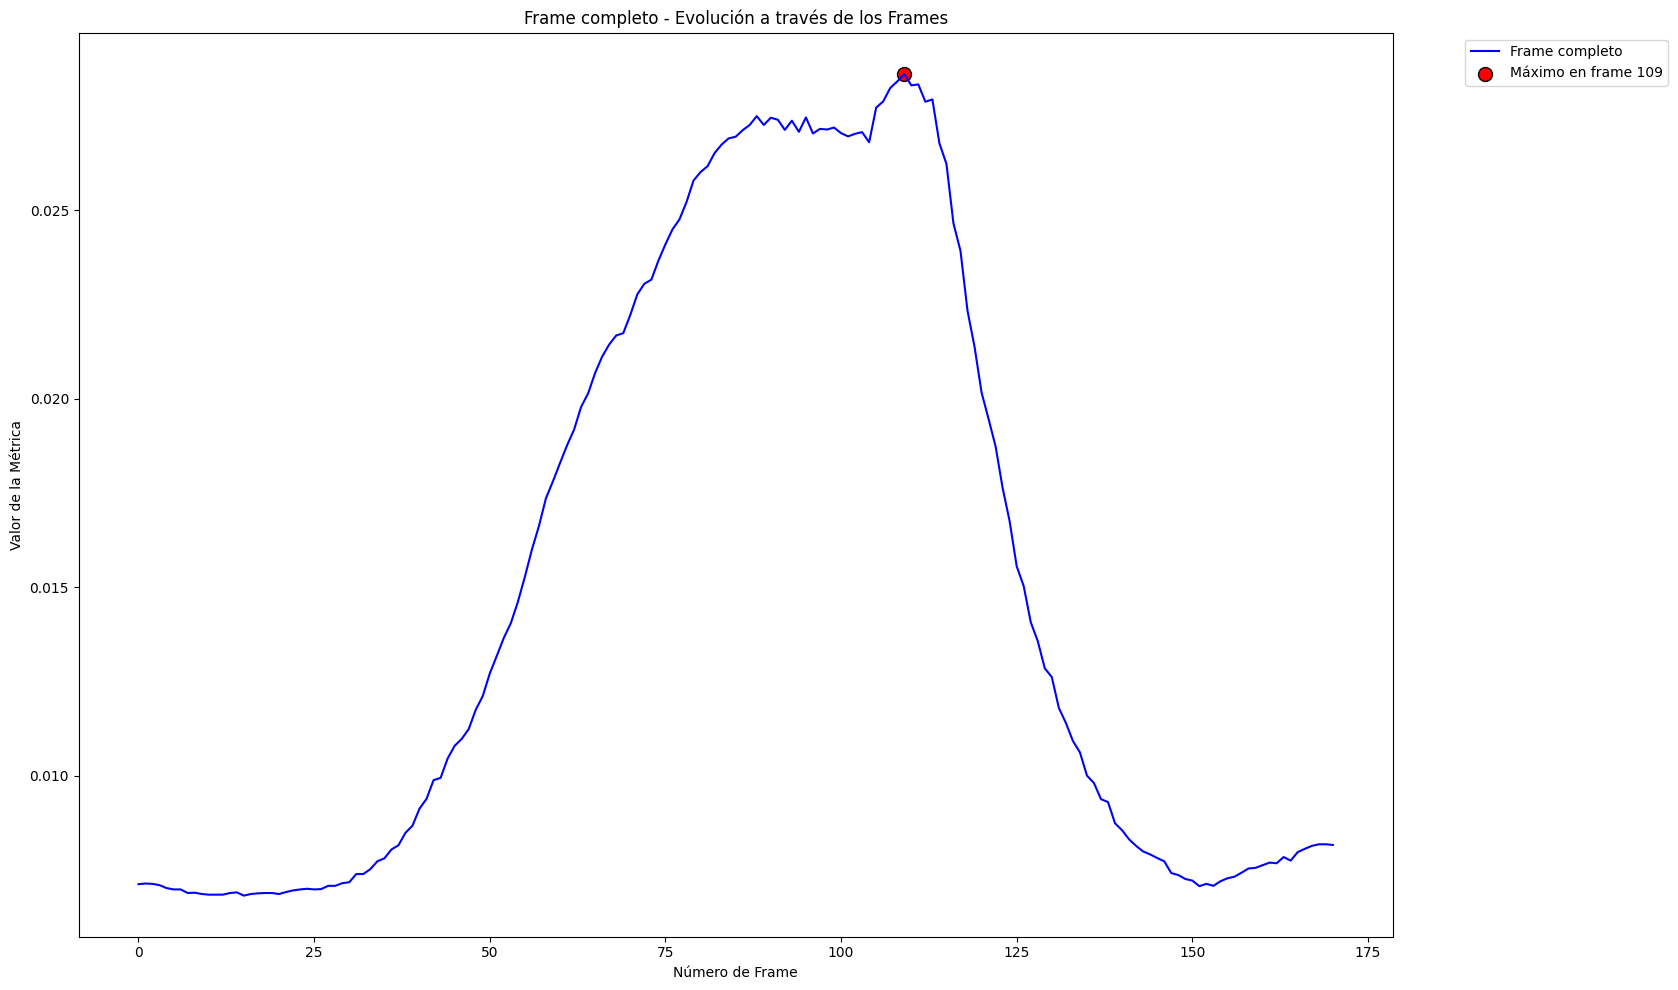

In [4]:
frames, metricas = obtener_metricas(video_path, None, calcular_metrica_enfoque)
frames, _ = resaltar_maximos(frames, metricas)
plot_metricas(metricas, "Frame completo")
reproducir_video(frames, "Frame completo")


---
### 1.2. Medición sobre una ROI ubicada en el centro del frame. Area de la ROI = 5 o 10% del area total del frame.

In [5]:
# ========================================
# GENERACIÓN DE ROIs
# ========================================

def generar_rois_centrados(fw, fh, n_rows, n_cols, roi_w, roi_h):
    """
    Genera una lista de Regiones de Interés (ROIs) dispuestas en una cuadrícula
    y centradas dentro de un marco de dimensiones dadas.

    Crea una cuadrícula de `n_rows` x `n_cols` ROIs. Cada ROI tiene un tamaño
    de `roi_w` x `roi_h`. Importante: La función asume y crea un espacio
    horizontal entre ROIs adyacentes igual a `roi_w` y un espacio vertical
    igual a `roi_h`. La cuadrícula completa (ROIs + espacios) se centra
    dentro del área definida por `fw` (ancho del marco) y `fh` (alto del marco).

    Args:
        fw (int): Ancho total del marco o imagen donde se centrarán las ROIs.
        fh (int): Alto total del marco o imagen donde se centrarán las ROIs.
        n_rows (int): Número de filas en la cuadrícula de ROIs.
        n_cols (int): Número de columnas en la cuadrícula de ROIs.
        roi_w (int): Ancho de cada ROI individual.
        roi_h (int): Alto de cada ROI individual.

    Returns:
        list[tuple[int, int, int, int]]: Una lista de tuplas. Cada tupla representa
                                         una ROI en formato (x, y, w, h), donde (x, y)
                                         es la coordenada superior izquierda, y (w, h)
                                         son el ancho y alto de la ROI. Retorna lista vacía
                                         si los parámetros son inválidos o la cuadrícula no cabe.
    """
    if n_rows <= 0 or n_cols <= 0 or roi_w <= 0 or roi_h <= 0 or fw <= 0 or fh <= 0:
        print("Error: Dimensiones deben ser positivas.")
        return []

    # Calcula el ancho total ocupado por la cuadrícula, incluyendo los espacios
    # La distancia entre el inicio de una ROI y la siguiente en la misma fila es 2*roi_w
    # El ancho total es: (n_cols-1) * (2*roi_w) + roi_w = 2*n_cols*roi_w - roi_w
    total_w = (2 * n_cols * roi_w) - roi_w if n_cols > 0 else 0
    # Calcula el alto total ocupado por la cuadrícula, incluyendo los espacios
    total_h = (2 * n_rows * roi_h) - roi_h if n_rows > 0 else 0

    if total_w > fw or total_h > fh:
        print(f"Error: La cuadrícula ({total_w}x{total_h}) es más grande que el frame ({fw}x{fh}).")
        return []

    # Calcula el offset (margen superior izquierdo) necesario para centrar la cuadrícula
    offset_x = (fw - total_w) // 2
    offset_y = (fh - total_h) // 2

    rois = []
    for i in range(n_rows): # Iterar sobre filas
        for j in range(n_cols): # Iterar sobre columnas
            # Calcula la coordenada X superior izquierda: offset + columna * (distancia entre inicios)
            current_x = offset_x + j * (2 * roi_w)
            # Calcula la coordenada Y superior izquierda: offset + fila * (distancia entre inicios)
            current_y = offset_y + i * (2 * roi_h)
            # Agrega la tupla (x, y, ancho_roi, alto_roi) a la lista
            rois.append((current_x, current_y, roi_w, roi_h))

    return rois

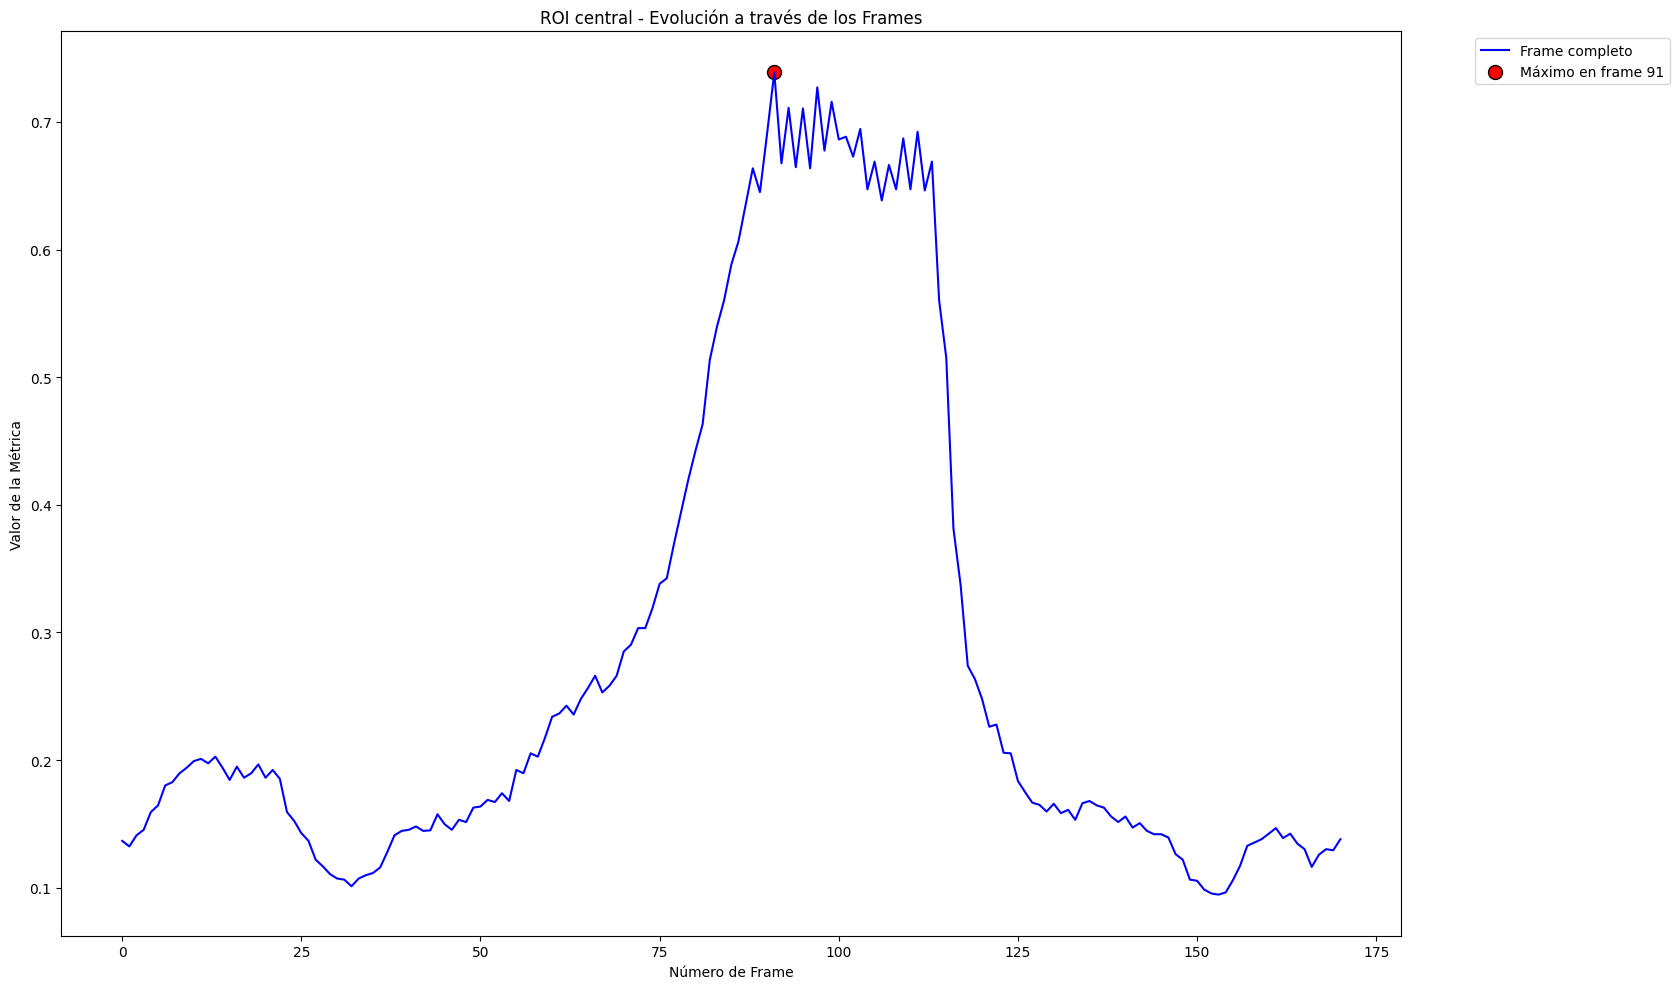

In [6]:
roi_w, roi_h = int(0.1 * w), int(0.1 * h)
roi_central = generar_rois_centrados(w, h, 1, 1, roi_w, roi_h)
frames, metricas = obtener_metricas(video_path, roi_central, calcular_metrica_enfoque)
frames, _ = resaltar_maximos(frames, metricas, roi_central)
plot_metricas(metricas[0], "ROI central")
reproducir_video(frames, "ROI central")


---
### 3. Medición sobre una matriz de enfoque compuesta por un arreglo de NxM elementos rectangulares equiespaciados. N y M son valores arbitrarios, probar con varios valores 3x3, 7x5, etc … (al menos 3) 

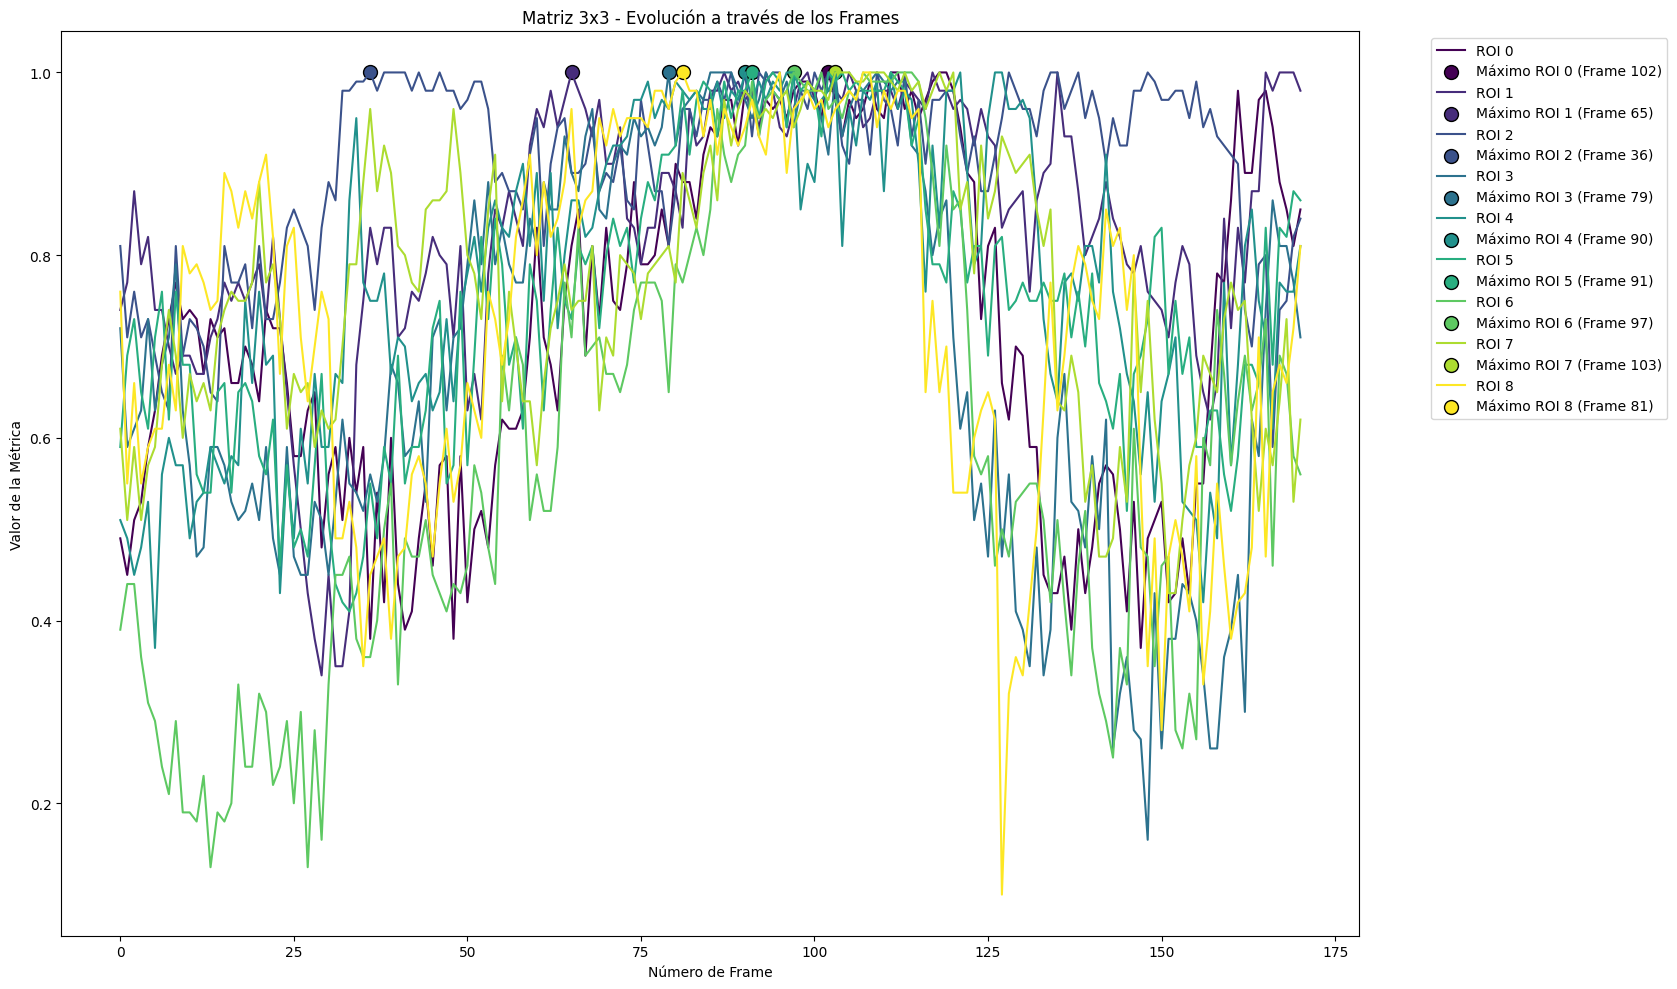

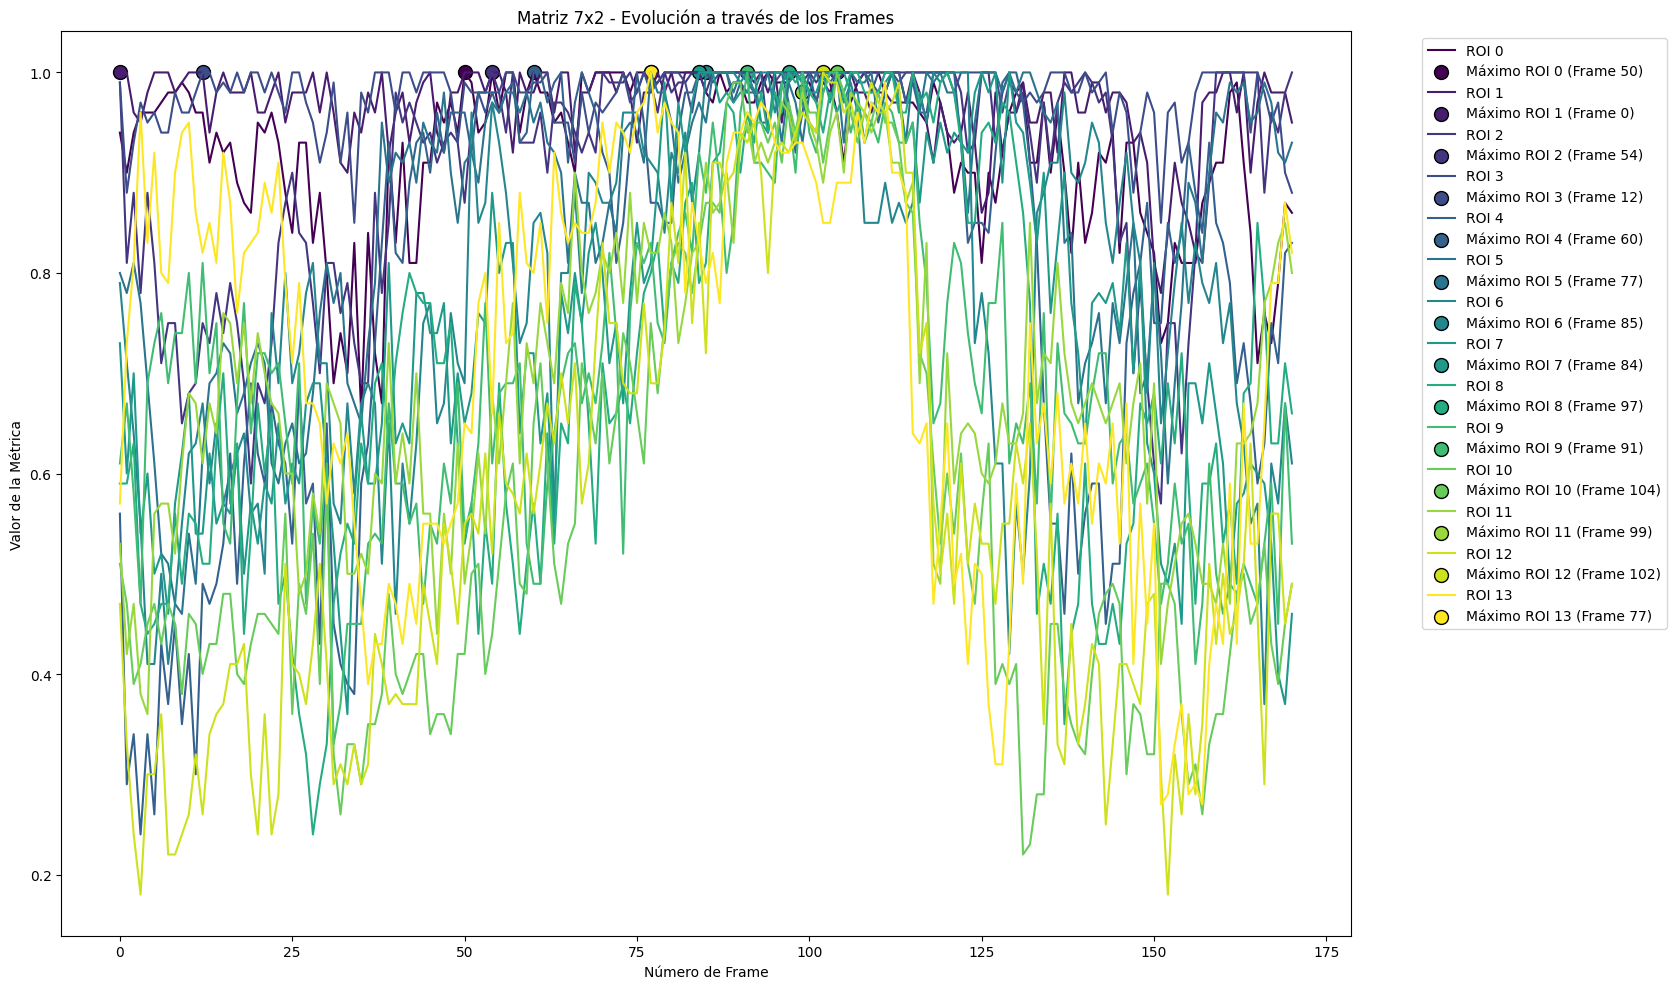

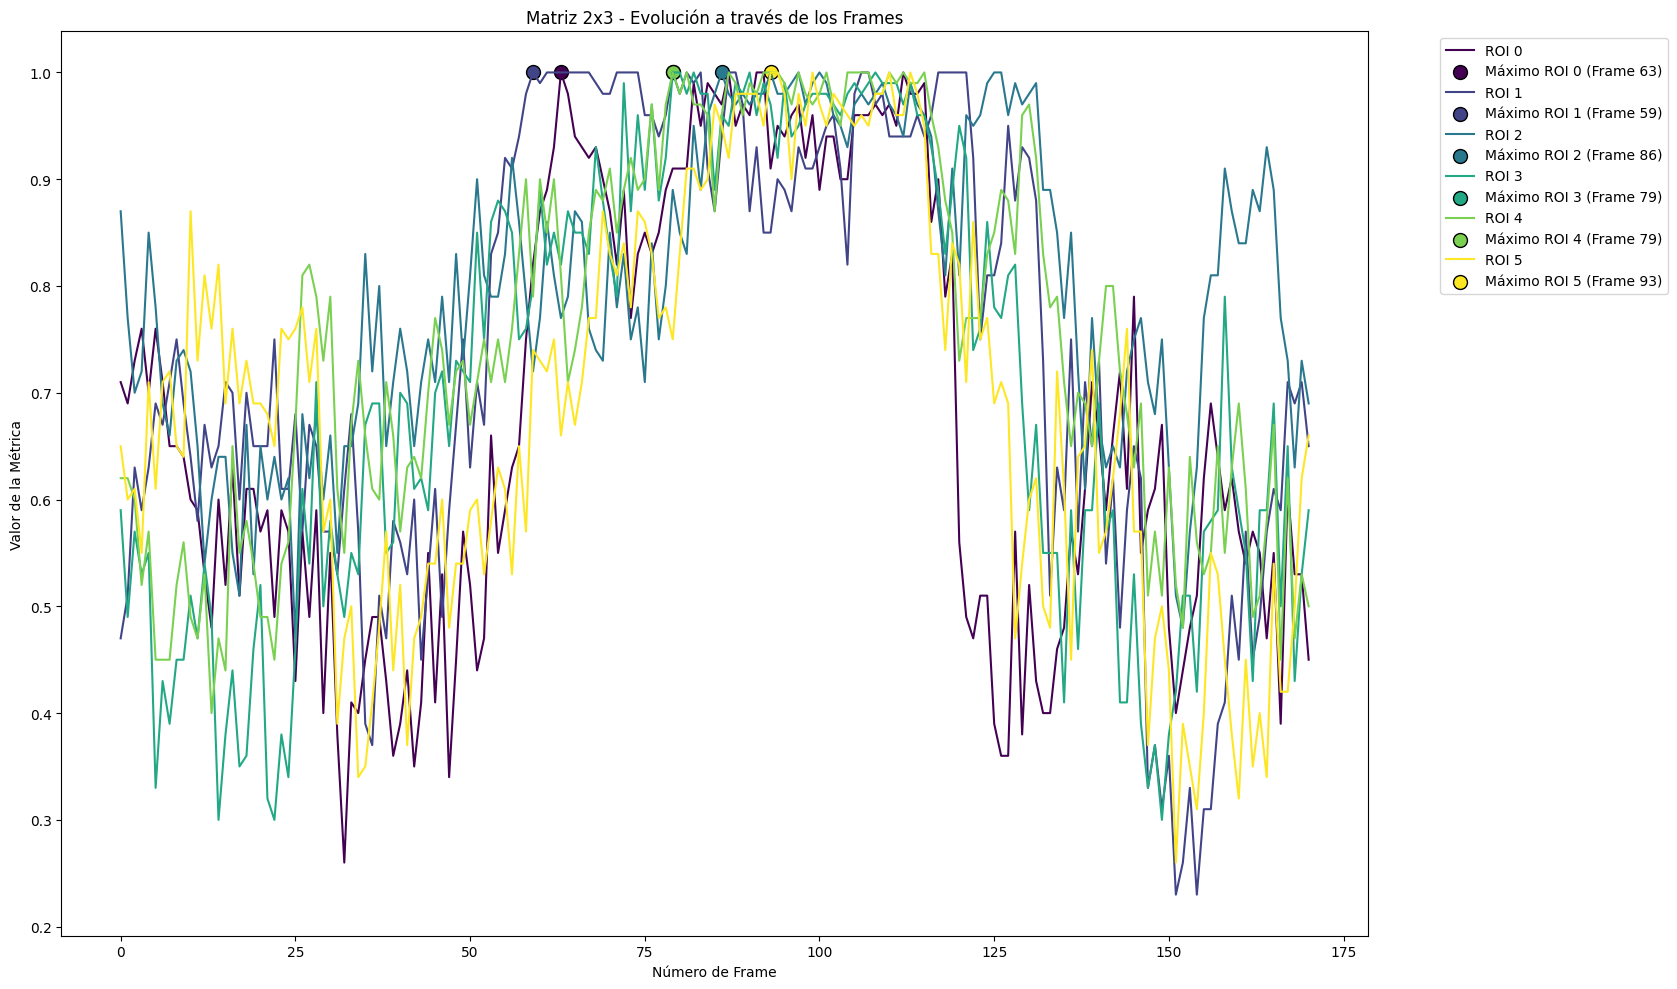

In [7]:
for n, m in [(3, 3), (7, 2), (2, 3)]:
    rois = generar_rois_centrados(w, h, n, m, 10, 10)
    frames, metricas = obtener_metricas(video_path, rois, calcular_metrica_enfoque)
    frames, _ = resaltar_maximos(frames, metricas, rois)
    plot_metricas(metricas, f"Matriz {n}x{m}")
    reproducir_video(frames, f"Matriz {n}x{m}")


---
## 2. Cambiar la métrica de enfoque eligiendo uno de los algoritmos explicados en el apéndice de: Analysis of focus measure operators in shapefrom focus

In [8]:
import cv2
import numpy as np

def modified_laplacian_focus_measure(gray_img):
    """
    Calcula una métrica de enfoque para una imagen en escala de grises
    utilizando el método del Laplaciano Modificado.

    Este método calcula la respuesta de aplicar filtros de segunda derivada
    ([-1, 2, -1]) separadamente en las direcciones horizontal (x) y vertical (y).
    La métrica final es la suma de los valores absolutos de estas respuestas
    sumados sobre toda la imagen. Un valor más alto indica mayor presencia
    de bordes y, por lo tanto, potencialmente mejor enfoque.

    Args:
        gray_img (np.ndarray): La imagen de entrada en escala de grises (2D NumPy array).
                               Se recomienda tipo de dato np.float32 o np.uint8.

    Returns:
        float: El valor de la métrica de enfoque del Laplaciano Modificado.
               Un número mayor generalmente indica una imagen más nítida.
    """
    # Definir los kernels 1D para la segunda derivada
    # Lx: Kernel horizontal [-1, 2, -1]
    Lx = np.array([-1, 2, -1], dtype=np.float32).reshape(1, -1)
    # Ly: Kernel vertical [-1, 2, -1]^T
    Ly = np.array([-1, 2, -1], dtype=np.float32).reshape(-1, 1)

    # Asegurar que la imagen de entrada sea flotante para evitar clipping con filter2D
    gray_img_float = gray_img.astype(np.float32)

    # Aplicar el filtro horizontal (segunda derivada en x)
    # ddepth=cv2.CV_32F asegura que la salida sea flotante
    delta_Lx = cv2.filter2D(gray_img_float, ddepth=cv2.CV_32F, kernel=Lx)
    # Aplicar el filtro vertical (segunda derivada en y)
    delta_Ly = cv2.filter2D(gray_img_float, ddepth=cv2.CV_32F, kernel=Ly)

    # Calcular el Laplaciano Modificado como la suma de los valores absolutos
    # de las respuestas en x e y para cada píxel.
    laplacian = np.abs(delta_Lx) + np.abs(delta_Ly)

    # La métrica de enfoque es la suma total de la respuesta del Laplaciano Modificado
    # sobre toda la imagen.
    return np.sum(laplacian)

def modified_laplacian_color(img_color):
    """
    Calcula la métrica de enfoque del Laplaciano Modificado para una imagen a color.

    Lo hace calculando la métrica de enfoque del Laplaciano Modificado
    (usando `modified_laplacian_focus_measure`) para cada canal de color
    individualmente y luego sumando los resultados de todos los canales.

    Args:
        img_color (np.ndarray): La imagen de entrada a color (3D NumPy array,
                                  generalmente en formato BGR para OpenCV).

    Returns:
        float: La suma de las métricas de enfoque del Laplaciano Modificado
               calculadas para cada canal de color. Un valor más alto
               generalmente indica una imagen más nítida.
    """
    # Separar la imagen a color en sus canales individuales (e.g., B, G, R)
    channels = cv2.split(img_color)

    # Calcular la métrica de enfoque para cada canal usando la función para escala de grises
    # y sumar los resultados.
    total_focus_measure = sum(modified_laplacian_focus_measure(ch) for ch in channels)

    return total_focus_measure



**Preparación del video y ROIs**

In [9]:
video_path = "focus_video.mov"

cap = cv2.VideoCapture(video_path)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()

# ROIs
roi_w, roi_h = int(0.1 * width), int(0.1 * height)
roi_central = generar_rois_centrados(width, height, 1, 1, roi_w, roi_h)

rois_dict = {
    "central": roi_central,
    "matriz_3x3": generar_rois_centrados(width, height, 3, 3, 10, 10),
    "matriz_7x2": generar_rois_centrados(width, height, 7, 2, 10, 10),
    "matriz_2x3": generar_rois_centrados(width, height, 2, 3, 10, 10),
}

#### Ejecución modified_laplacian_color
**2.1. Todo el frame**

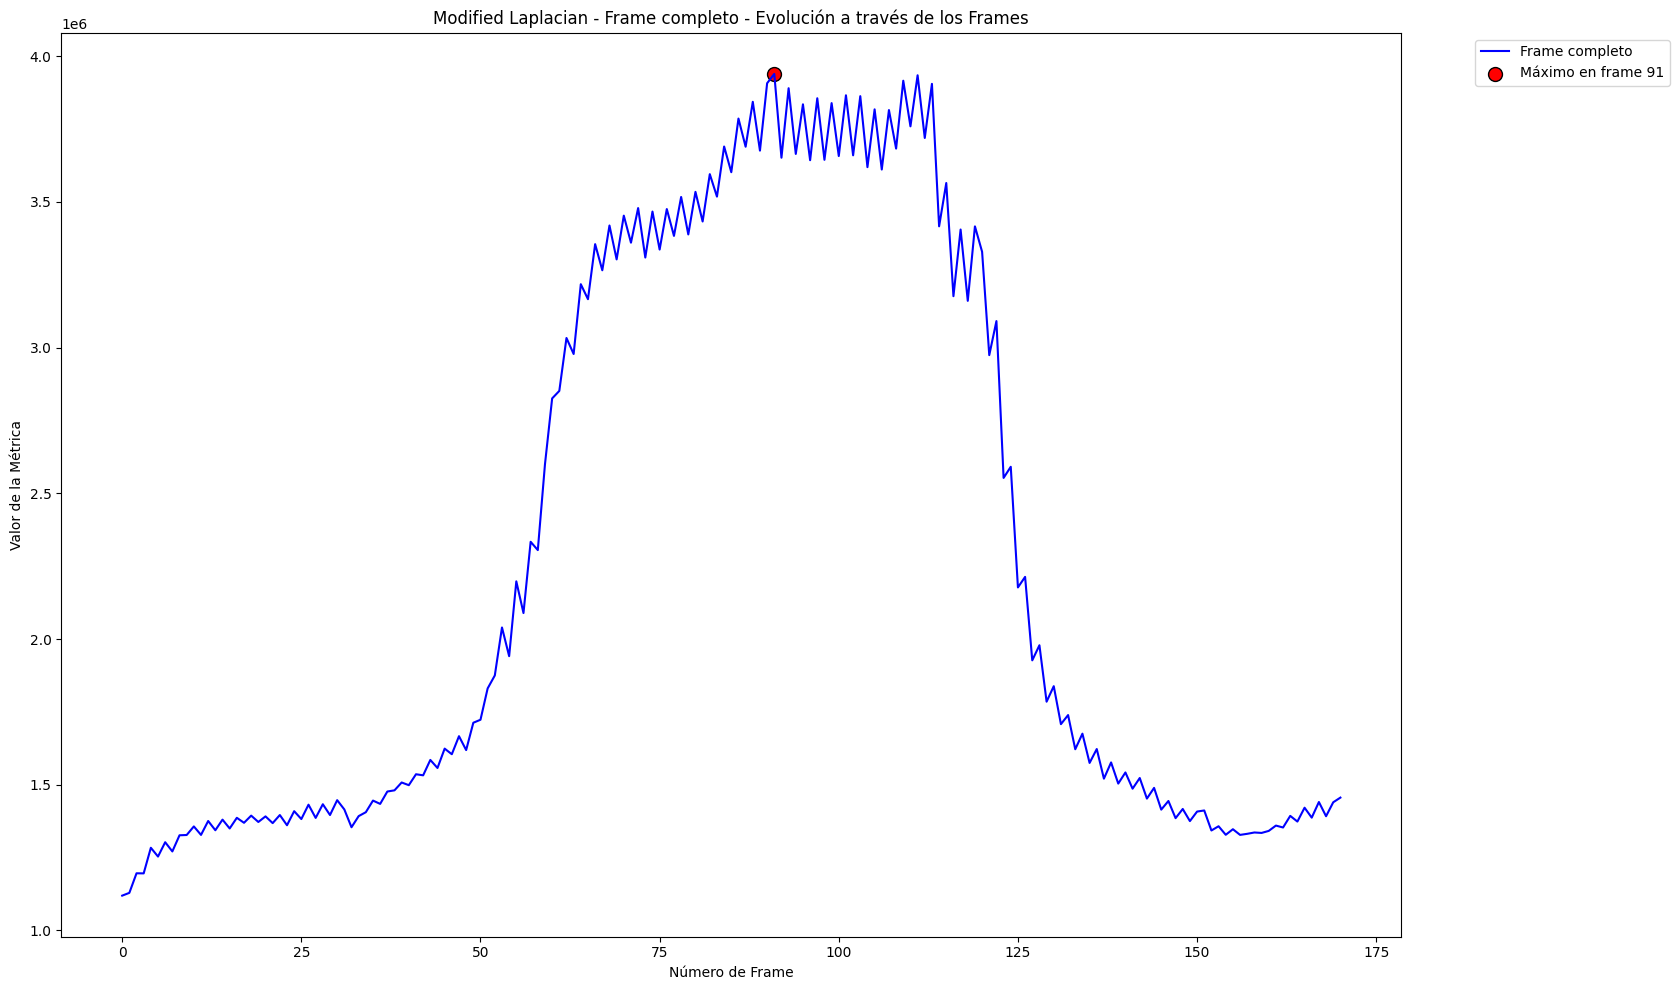

In [10]:
frames, metricas = obtener_metricas(video_path, None, modified_laplacian_color)
frames, _ = resaltar_maximos(frames, metricas)
plot_metricas(metricas, "Modified Laplacian - Frame completo")
reproducir_video(frames, "Modified Laplacian - Frame completo")


**2.2. ROI central**

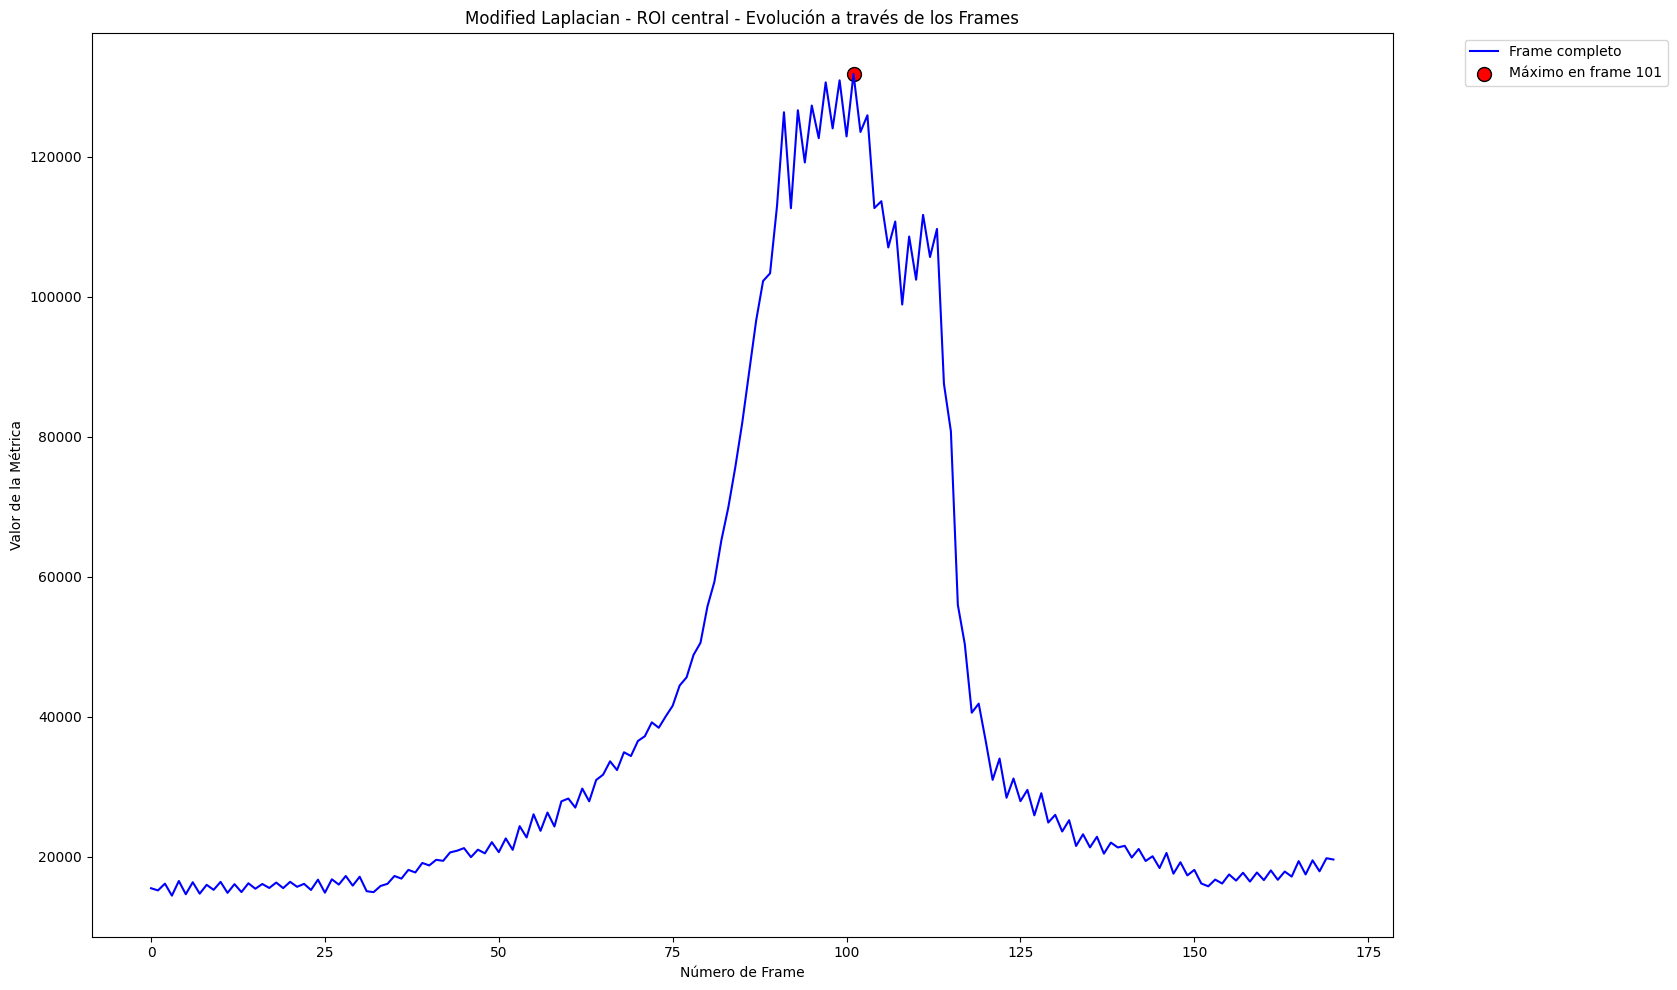

In [11]:
frames, metricas = obtener_metricas(video_path, rois_dict["central"], modified_laplacian_color)
frames, _ = resaltar_maximos(frames, metricas, rois_dict["central"])
plot_metricas(metricas[0], "Modified Laplacian - ROI central")
reproducir_video(frames, "Modified Laplacian - ROI central")

**2.3. Matrices NxM**

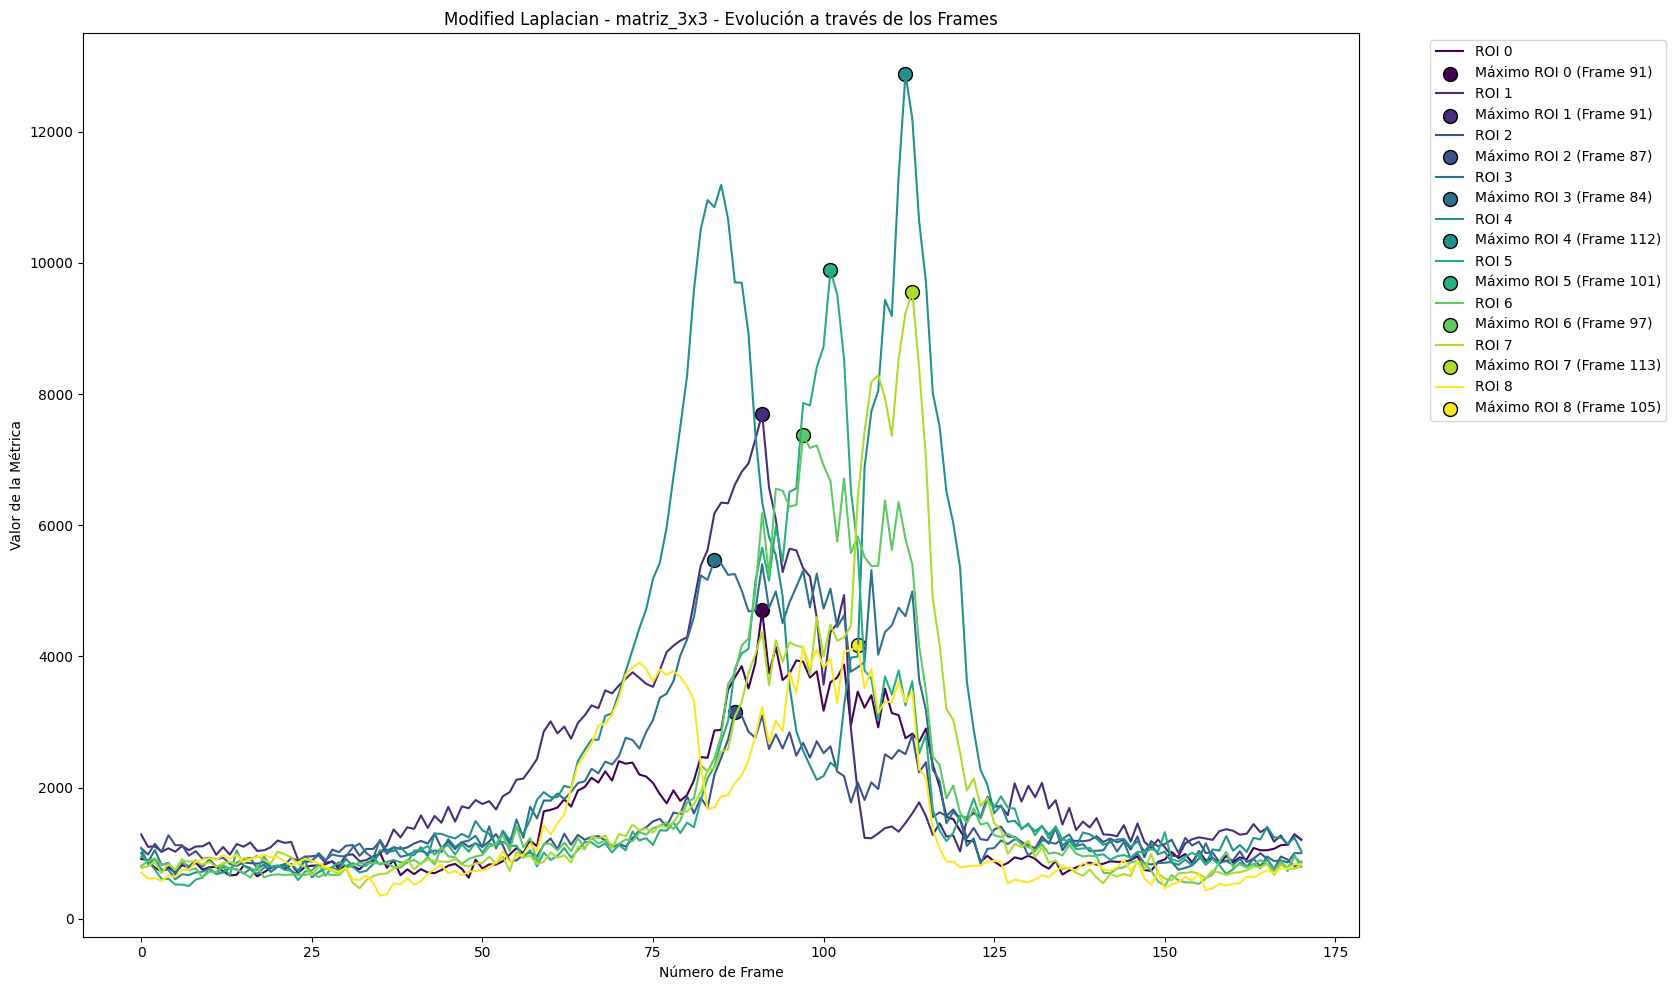

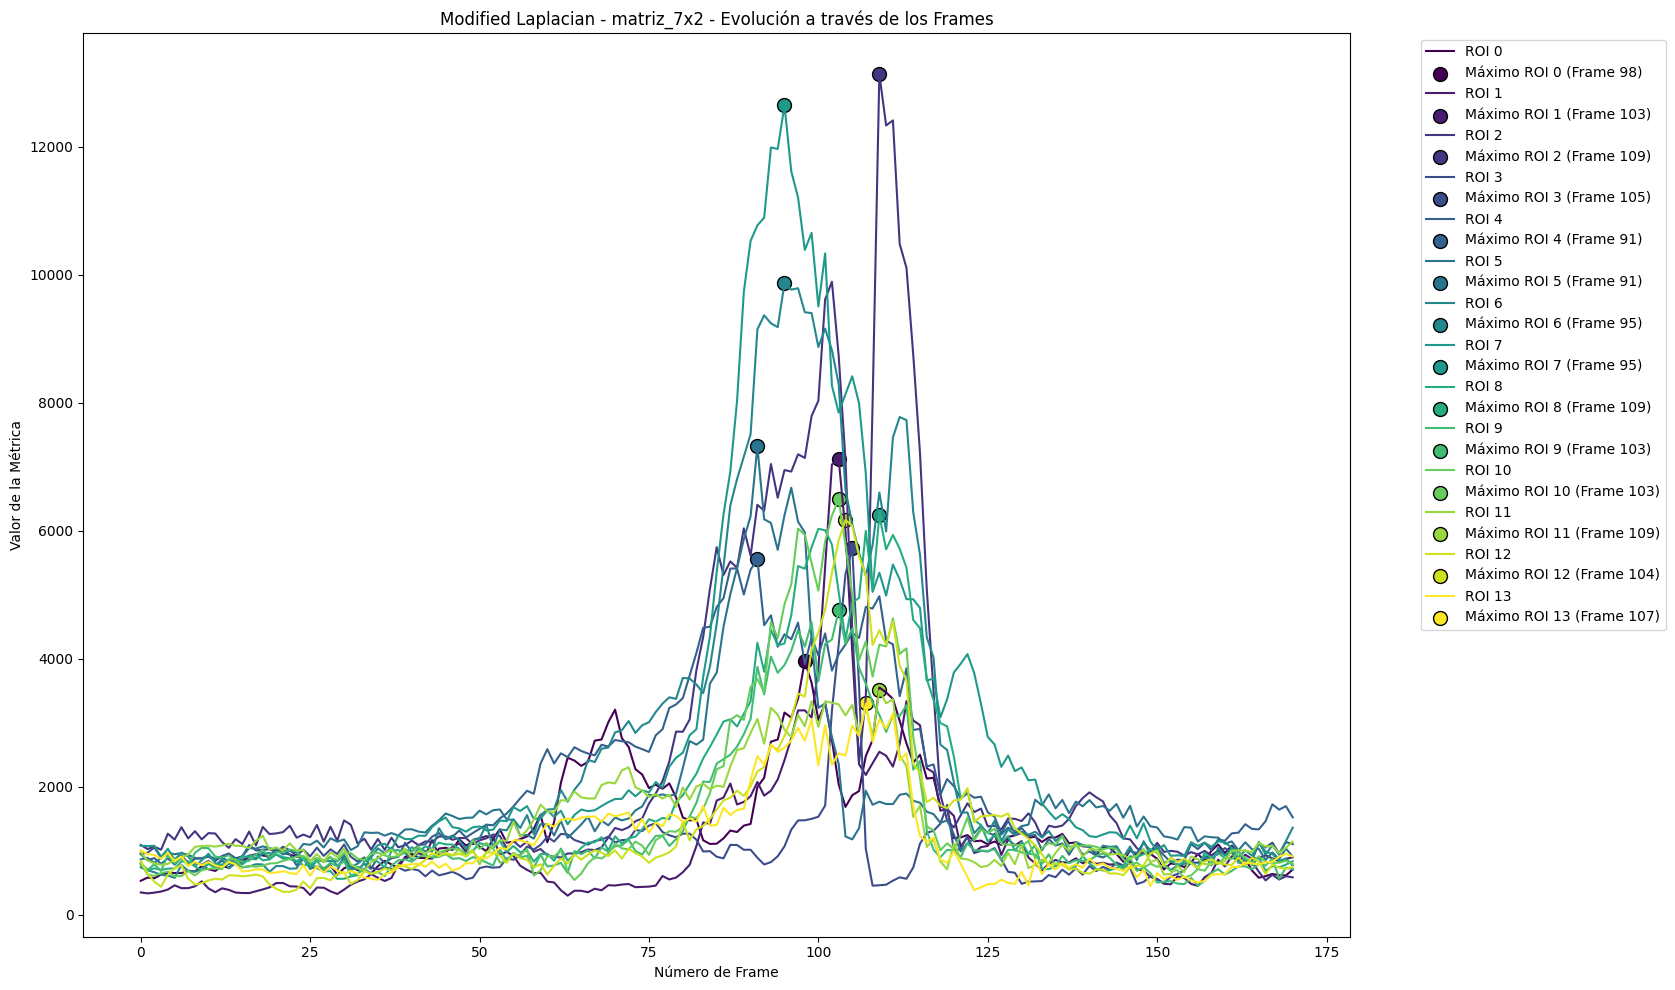

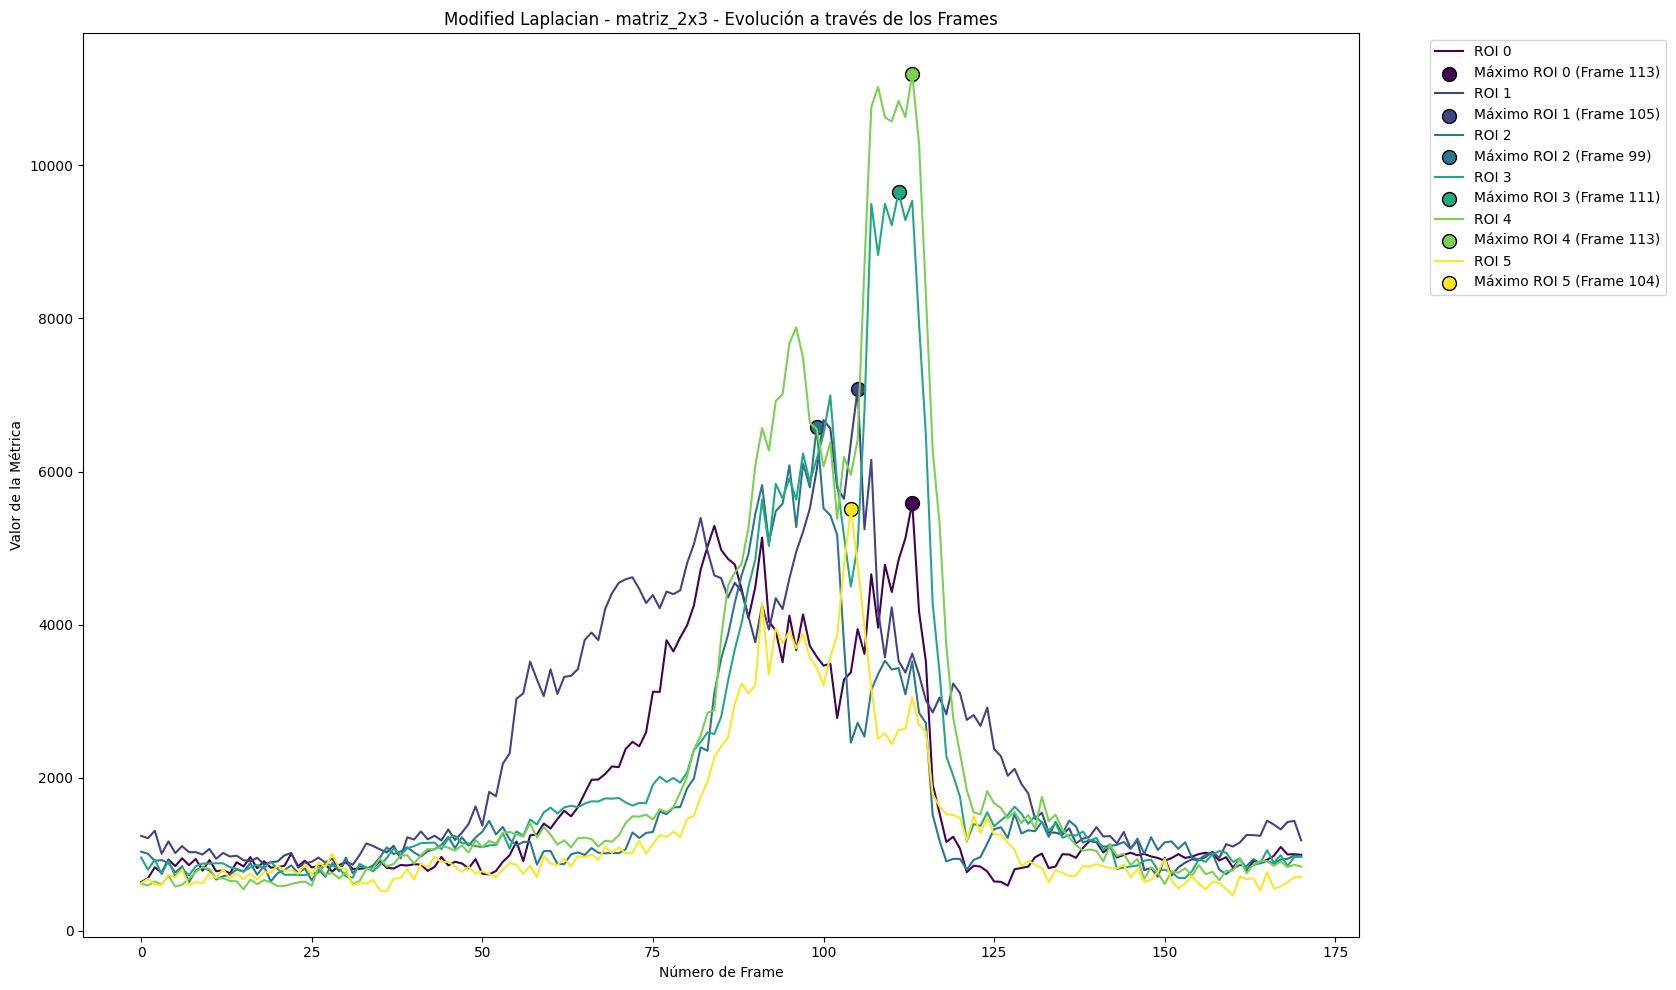

In [12]:
for nombre, rois in rois_dict.items():
    if nombre == "central":
        continue

    frames, metricas = obtener_metricas(video_path, rois, modified_laplacian_color)
    frames, _ = resaltar_maximos(frames, metricas, rois)
    plot_metricas(metricas, f"Modified Laplacian - {nombre}")
    reproducir_video(frames, f"Modified Laplacian - {nombre}")


---
## Puntos extra: Aplicar unsharp masking para expandir la zona de enfoque y devolver

In [13]:
# =====================================================================
# PROCESAMIENTO DE VIDEO - CÁLCULO DE MÉTRICAS CON PREPROCESAMIENTO
# =====================================================================

def unsharp_masking(img, k=2.5):
    """
    Aplica el algoritmo de 'unsharp masking' para realzar la nitidez de una imagen.
    (Docstring detallada omitida por brevedad, ver respuestas anteriores)
    """
    gauss = cv2.GaussianBlur(img, (7, 7), 0.5)
    sharpened = cv2.addWeighted(img, k+1, gauss, -k, 0)
    return sharpened

def calcular_metricas_video_con_preproceso(video_path, rois=None, metric_func=None, preprocessing_func=None):
    """
    Procesa un video para calcular una métrica sobre cada frame (o sus ROIs),
    después de aplicar opcionalmente una función de preprocesamiento.

    Lee cada frame, aplica `preprocessing_func` (si se proporciona) y luego
    calcula `metric_func` sobre el frame resultante (preprocesado o no).
    Dibuja rectángulos en una copia de los frames (post-preprocesamiento)
    para indicar las áreas procesadas.

    Args:
        video_path (str): Ruta al archivo de video.
        rois (list[tuple], optional): Lista de ROIs (x, y, w, h). Si es None,
                                      se procesa el frame completo. Default None.
        metric_func (callable, optional): Función para calcular la métrica (acepta
                                           imagen NumPy, devuelve número). Si es None,
                                           se almacena 0. Default None.
        preprocessing_func (callable, optional): Función para preprocesar CADA frame
                                                 ANTES de calcular la métrica. Debe
                                                 aceptar un frame y devolver un frame.
                                                 Default None (sin preprocesamiento).

    Returns:
        tuple: (frames_procesados_con_rectangulos, metricas)
            - frames_procesados_con_rectangulos (list[np.ndarray]): Lista de frames
              (posiblemente preprocesados) con rectángulos rojos dibujados.
            - metricas (list[float] | list[list[float]]): Lista(s) de métricas calculadas
              sobre los datos (posiblemente preprocesados).

    Diferencia con `calcular_metricas_video_base`:
        - Tiene el parámetro `preprocessing_func`.
        - Aplica `preprocessing_func` al frame ANTES de calcular la métrica.
        - La métrica se calcula sobre los datos resultantes del preprocesamiento.
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error: No se pudo abrir el video en {video_path}")
        return [], []

    metricas = [[] for _ in range(len(rois))] if rois else []
    frames_procesados_con_rectangulos = []
    frame_count = 0

    while cap.isOpened():
        ret, frame_original = cap.read()
        if not ret:
            break

        # Aplica preprocesamiento si se especificó
        if preprocessing_func:
            frame_procesado = preprocessing_func(frame_original)
        else:
            frame_procesado = frame_original # Usa el original si no hay preproceso

        # Copia para dibujar, DESPUÉS del preprocesamiento
        frame_para_dibujar = frame_procesado.copy()
        color_rectangulo = (0, 0, 255) # Rojo BGR

        if rois:
            for i, roi_coords in enumerate(rois):
                x, y, w, h = roi_coords
                fh, fw = frame_procesado.shape[:2] # Dimensiones del frame procesado
                if x < 0 or y < 0 or w <= 0 or h <= 0 or x + w > fw or y + h > fh:
                    print(f"Advertencia: ROI {i} {roi_coords} inválida/fuera de límites en frame {frame_count} (post-proceso). Saltando.")
                    continue

                # Extrae ROI del frame PROCESADO
                roi_frame = frame_procesado[y:y+h, x:x+w]
                # Calcula métrica sobre ROI PROCESADO
                metrica_valor = metric_func(roi_frame) if metric_func else 0
                metricas[i].append(metrica_valor)
                # Dibuja en la copia
                cv2.rectangle(frame_para_dibujar, (x, y), (x+w, y+h), color_rectangulo, 2)
        else:
            # Calcula métrica sobre frame PROCESADO completo
            metrica_valor = metric_func(frame_procesado) if metric_func else 0
            metricas.append(metrica_valor)
            # Dibuja en la copia
            # cv2.rectangle(frame_para_dibujar, (0, 0), (fw-1, fh-1), color_rectangulo, 2)

        frames_procesados_con_rectangulos.append(frame_para_dibujar)
        frame_count += 1

    cap.release()
    print(f"Procesados {frame_count} frames (Con Preproceso Opcional).")
    return frames_procesados_con_rectangulos, metricas

In [14]:

video_path = "focus_video.mov"
cap = cv2.VideoCapture(video_path)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()



Procesados 171 frames (Con Preproceso Opcional).


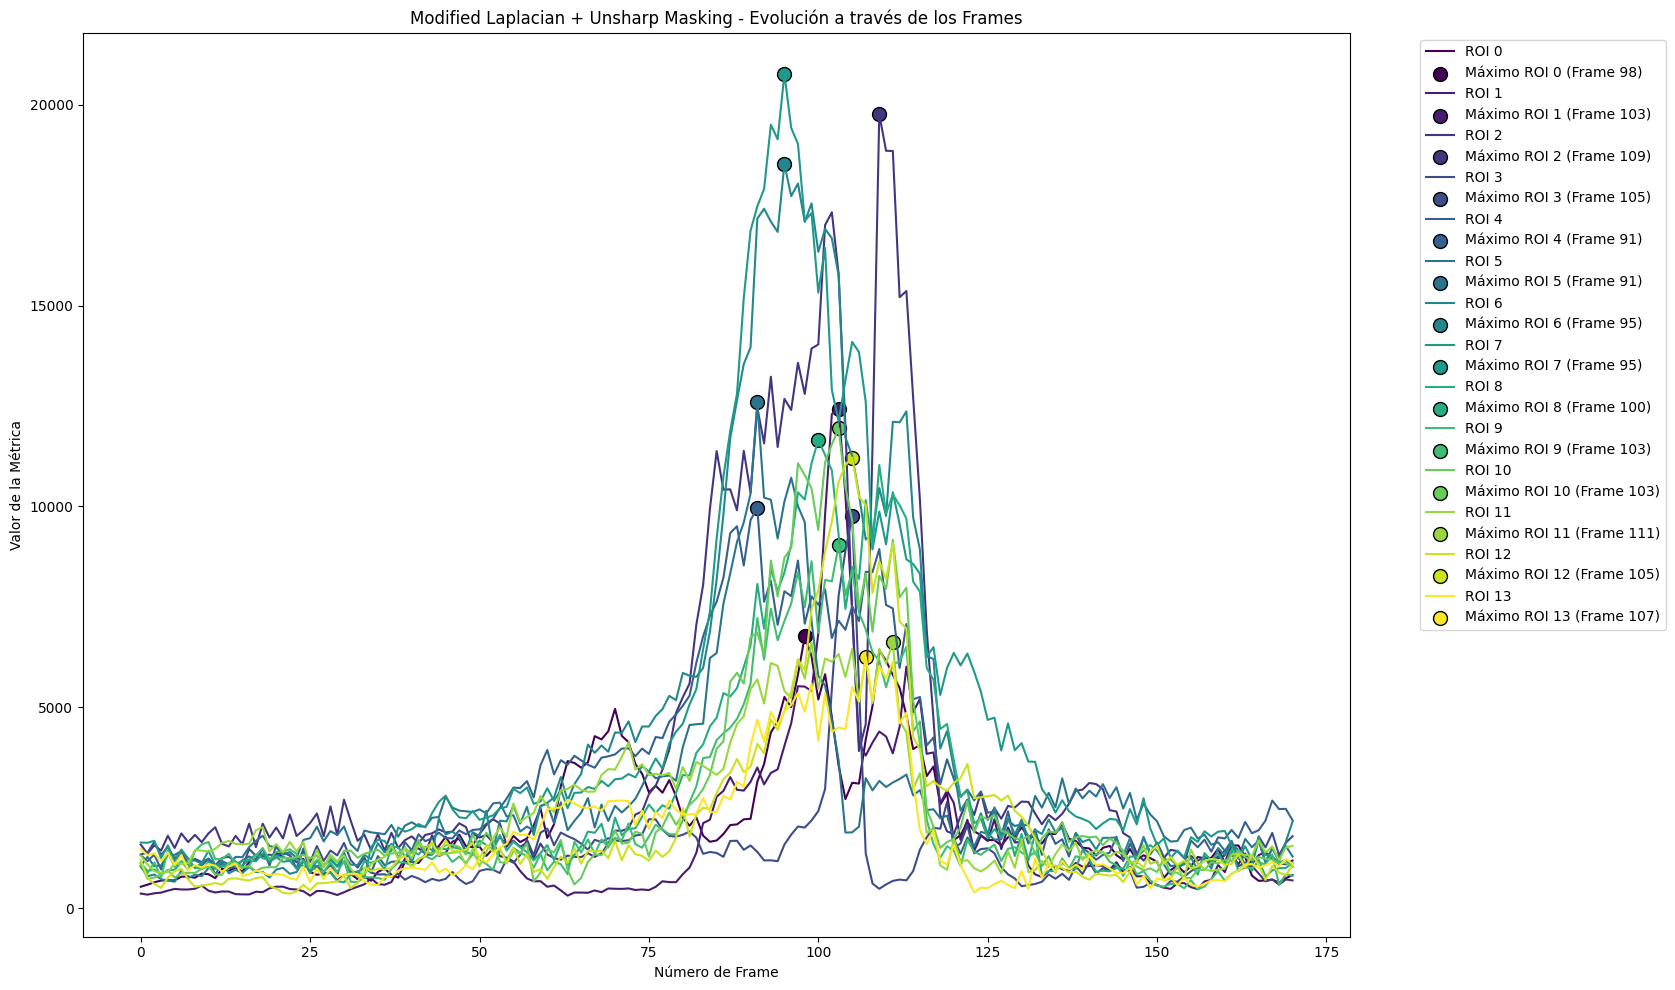

In [15]:
# Generar ROIs para una matriz 7x2
rois = generar_rois_centrados(width, height, 7, 2, 10, 10)

# Ejecutar con unsharp masking + modified laplacian
frames, metricas = calcular_metricas_video_con_preproceso(
    video_path,
    rois=rois,
    metric_func=modified_laplacian_color,
    preprocessing_func=unsharp_masking
)

# Resaltar máximos y mostrar resultados
frames, _ = resaltar_maximos(frames, metricas, rois)
plot_metricas(metricas, "Modified Laplacian + Unsharp Masking")
reproducir_video(frames, "Modified Laplacian + Unsharp Masking")